Regression Group Project

Dataset - california_housing (20,640 block groups, 8 numeric features)

Target - MedHouseVal - median house value, in hundreds of thousands of dollars

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

df = pd.read_csv("california.csv")
TARGET = "MedHouseVal"
FEATURES = [c for c in df.columns if c != TARGET]

print("shape    : ", df.shape)
print("features : ", FEATURES)
df.head()

shape    :  (20640, 9)
features :  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.2500,39.0,4.503205,1.073718,1109.0,1.777244,34.06,-118.36,3.550
1,1.9784,37.0,4.988584,1.038813,1143.0,2.609589,36.78,-119.78,0.707
2,4.0132,46.0,4.480296,1.012315,1534.0,3.778325,37.73,-122.42,2.294
3,1.5208,52.0,3.908046,1.114943,200.0,2.298851,37.81,-122.28,1.125
4,5.1795,37.0,5.406360,1.024735,711.0,2.512367,33.82,-118.13,2.254


In [2]:
print("missing values per column: ")
print(df.isna().sum().to_string())
print("\nduplicated rows: ", df.duplicated().sum())
df.describe().T.round(3)

missing values per column: 
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0

duplicated rows:  0


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000


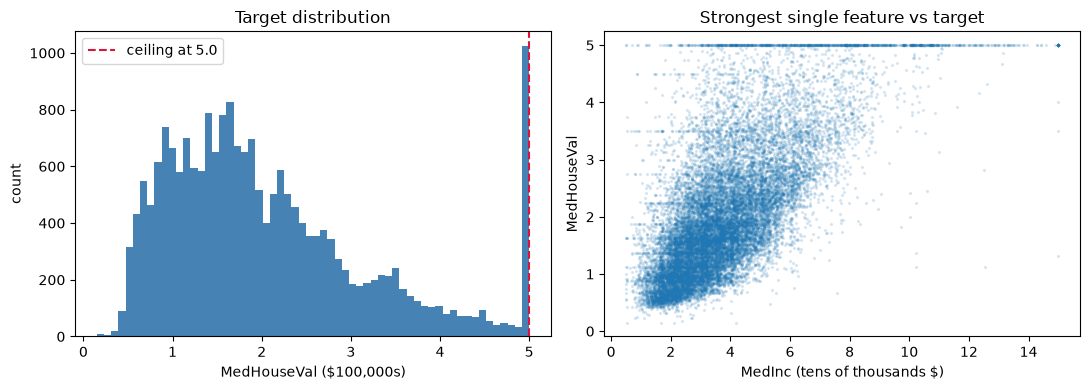

rows at the 5.0 ceiling: 992 (4.8%)


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(df[TARGET], bins=60, color="steelblue")
ax[0].axvline(5.0, color="crimson", ls="--", lw=1.5, label="ceiling at 5.0")
ax[0].set_xlabel("MedHouseVal ($100,000s)")
ax[0].set_ylabel("count")
ax[0].set_title("Target distribution")
ax[0].legend()

ax[1].scatter(df["MedInc"], df[TARGET], s=2, alpha=0.12)
ax[1].set_xlabel("MedInc (tens of thousands $)")
ax[1].set_ylabel("MedHouseVal")
ax[1].set_title("Strongest single feature vs target")

plt.tight_layout()
plt.show()

capped = int((df[TARGET] >= 5.0).sum())
print(f"rows at the 5.0 ceiling: {capped} ({capped / len(df):.1%})")

Result 1 - the target is censored, values are capped to 5 ($500,000). every block gorup
worth more was recorded at 5.0. No model can predict past ceeling the data imposes, so
rows are gauranteed error - they'll show up as a srip in predicted vs actual plot 

In [4]:
for c in ["AveRooms", "AveBedrms", "AveOccup", "Population"]:
    s = df[c]
    print(f"{c:11s} median {s.median():8.2f} 99.5th pct {s.quantile(0.995):9.2f} max {s.max():10.2f}")

AveRooms    median     5.23 99.5th pct     15.75 max     141.91
AveBedrms   median     1.05 99.5th pct      3.11 max      34.07
AveOccup    median     2.82 99.5th pct      6.12 max    1243.33
Population  median  1166.00 99.5th pct   7233.64 max   35682.00


Result 2 - extreme outlliers in the per-household averages. 'AveRooms' and 'AveOccup'
tuny block groups, or non residential sites, make average meaningless. since "one crazy
line drag the entire pitfall"

In [5]:
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("correlation with the target")
print(corr.round(3).to_string())

correlation with the target
MedInc        0.688
AveRooms      0.152
Latitude     -0.144
HouseAge      0.106
AveBedrms    -0.047
Longitude    -0.046
Population   -0.025
AveOccup     -0.024


In [6]:
# Exploring Done

In [7]:
N_TRAIN = int(0.75 * len(df))
train = df.iloc[:N_TRAIN].copy()
test = df.iloc[N_TRAIN:].copy()

print(f"train: {train.shape[0]} rows")
print(f"test: {test.shape[0]} rows")
print(f"\ntrain mean target: {train[TARGET].mean():.3f}")
print(f"test mean target: {test[TARGET].mean():.3f}")

train: 15480 rows
test: 5160 rows

train mean target: 2.066
test mean target: 2.076


above was to split and copy train and test data, and then find the average's of both
training and test data to see they are closer to each other otherwise split isn't
representive

In [8]:
def evaluate(feats, tr=None, te=None, model=None, label=""):
    """Fit on the training rows only, score on the held-back test rows."""
    tr = train if tr is None else tr
    te = test if te is None else te
    model = LinearRegression() if model is None else model

    model.fit(tr[feats], tr[TARGET])
    pred = model.predict(te[feats])
    yte = te[TARGET]

    return {
        "label": label or f"{len(feats)} features",
        "feats": feats,
        "R2": r2_score(yte, pred),
        "RMSE": np.sqrt(mean_squared_error(yte, pred)),
        "MAE": mean_absolute_error(yte, pred),
        "model": model,
        "pred": pred,
    }

base = evaluate(FEATURES, label="OLS, all 8 features")

print(f"test R2 : {base['R2']:.4f}")
print(f"test RMSE : {base['RMSE']:.4f} = ${base['RMSE'] * 100_000:,.0f}")
print(f"test MAE : {base['MAE']:.4f} = ${base['MAE'] * 100_000:,.0f}")

test R2 : 0.5897
test RMSE : 0.7400 = $73,996
test MAE : 0.5318 = $53,182


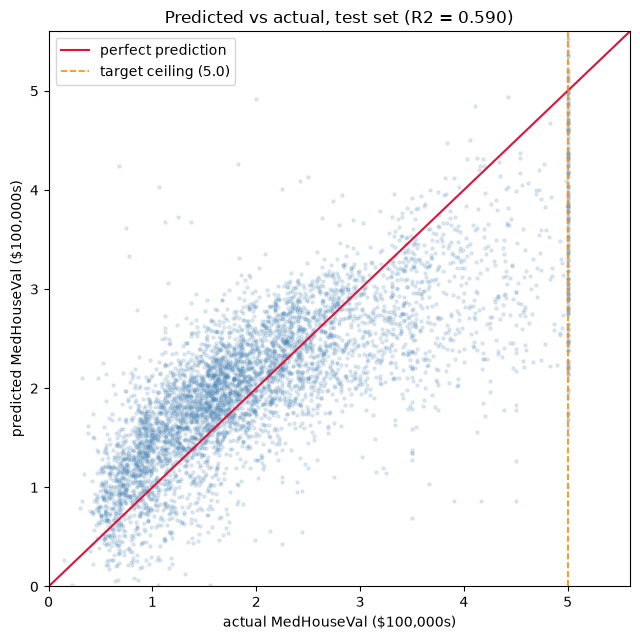

In [9]:
yte = test[TARGET]
pred = base["pred"]

plt.figure(figsize=(6.5, 6.5))
plt.scatter(yte, pred, s=5, alpha=0.15, color="steelblue")
lims = [0, 5.6]
plt.plot(lims, lims, color="crimson", lw=1.5, label="perfect prediction")
plt.axvline(5.0, color="darkorange", ls="--", lw=1.2, label="target ceiling (5.0)")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("actual MedHouseVal ($100,000s)")
plt.ylabel("predicted MedHouseVal ($100,000s)")
plt.title(f"Predicted vs actual, test set (R2 = {base['R2']:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=120)
plt.show()

Reading this graph, we can say the points hug the diagnol throug hthe middle of the range,

so model works reasonably well, but however two visible defects include:

The verticle stripe at x = 5.0 is the censored target from Finding 1. A data limitation, not a modelling failure.

Some predictions fall below zero, nothing contraints a linear model to a positive output.

Clipping at 0 would be legitimate post-processing.

In [10]:
m = base["model"]

coefs = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": m.coef_,
    "$ per +1 unit": m.coef_ * 100_000,
}).sort_values("coefficient", key=abs, ascending=False)

print(f"intercept: {m.intercept_:.4f}\n")
coefs.round(2)

intercept: -37.1417



,feature,coefficient,$ per +1 unit
3,AveBedrms,0.82,82245.04
0,MedInc,0.45,44872.24
7,Longitude,-0.43,-43421.89
6,Latitude,-0.42,-41772.80
2,AveRooms,-0.13,-13381.10
1,HouseAge,0.01,958.36
5,AveOccup,-0.00,-404.52
4,Population,-0.00,-0.06


AvgBedrms positive meaning, more bedrooms, cost of houses go up. Expected, since
its a core part of the house

MedInc positive, meaning richer districts, pricier houses and would also be a good sensible driver

Longitude and Latitude both towards negative, the model is trying to describe California's costline with two straight lines. Real prices depend on a distance to the coast, which is not linear in either coordinate.

AveRooms is also negative which looks wrong since averooms and avgbedrooms should be highly
corelated, this is due to multicollinearity, meaning they are strongly related to each other
so the model has trouble determining their individual effects. so we cant't gauge their
coefficient individually.

HouseAge also slighlty positive, though doesn't make a lot of sense but maybe because of 
california's old housing stock that sits estabilished, and like expensive coastal cities. so that age procies for a location.

AvgOccup and Population - both effectively zero, meaning the ablation agrees that removin them changes nothing.

'MedInc' dominates, latitude and longitude are a distant second and third, and the remaining features are noise. 

In [11]:
rows = []
for f in FEATURES:
    keep = [c for c in FEATURES  if c!= f]
    rows.append({"dropped": f, "test R2": evaluate(keep)["R2"]})

abl = pd.DataFrame(rows)
abl ["change vs all 8"] = abl ["test R2"] - base ["R2"]
abl = abl.sort_values("change vs all 8")

print(f"all 8 features: test R2 = {base['R2']:.4f}\n")
abl.round(4)

# Removing a feature ike MedInc drops R2 by a lot and hurts the model.
# Otherway around if dropping a feature, increases R2 could mean its adding noise
# or instability.

all 8 features: test R2 = 0.5897



,dropped,test R2,change vs all 8
0,MedInc,0.3884,-0.2013
6,Latitude,0.5170,-0.0728
7,Longitude,0.5225,-0.0672
1,HouseAge,0.5825,-0.0073
4,Population,0.5897,-0.0000
5,AveOccup,0.5899,0.0002
2,AveRooms,0.5932,0.0034
3,AveBedrms,0.5946,0.0049


In [12]:
for d in (train, test):
    d["RoomsPerPerson"] = d["AveRooms"] / d["AveOccup"]
    d["BedrmRatio"] = d["AveBedrms"] / d["AveRooms"]

ENGINEERED = FEATURES + ["RoomsPerPerson", "BedrmRatio"]
eng = evaluate(ENGINEERED, label="OLS + 2 engineered")

print(f"baseline(8 features) : R2 = {base['R2']:.4f}")
print(f"+ RoomsPerPerson, BedrmRatio : R2 = {eng['R2']:.4f} (change {eng['R2'] - base['R2']:+.4f})")

# Engineering two features to see if it improves the model and it does!

baseline(8 features) : R2 = 0.5897
+ RoomsPerPerson, BedrmRatio : R2 = 0.6589 (change +0.0692)


In [13]:
CANDIDATES = {
    "all 8 (baseline)": FEATURES,
    "drop AveBedrms": [f for f in FEATURES if f != "AveBedrms"],
    "drop both room columns": [f for f in FEATURES if f not in ("AveRooms", "AveBedrms")],
    "drop rooms + Population": [f for f in FEATURES if f not in ("AveRooms", "AveBedrms", "Population")],
    "lean + engineered": ["MedInc", "HouseAge", "AveOccup", "Latitude", "Longitude", "RoomsPerPerson", "BedrmRatio"],
}

cand_rows = [{"feature set": k, "n": len(v), "test R2": evaluate(v)["R2"]}
             for k, v in CANDIDATES.items()]

# keep lean model as named result for last cells
lean = evaluate(CANDIDATES["lean + engineered"], label = "lean + engineered")

pd.DataFrame(cand_rows).sort_values("test R2", ascending=False).round(4)

,feature set,n,test R2
4,lean + engineered,7,0.6252
1,drop AveBedrms,7,0.5946
2,drop both room columns,6,0.5921
3,drop rooms + Population,5,0.5921
0,all 8 (baseline),8,0.5897


In [14]:
hi_rooms = train["AveRooms"].quantile(0.995)
hi_occup = train["AveOccup"].quantile(0.995)
keep_mask = (train["AveRooms"] <= hi_rooms) & (train["AveOccup"] <= hi_occup)
train_trim = train[keep_mask]

dropped = int((~keep_mask).sum())
print(f"dropped {dropped} of {len(train)} training rows ({dropped / len(train):.2%})")
print(f"thresholds: AveRooms <= {hi_rooms:.2f}, AveOccup <= {hi_occup:.2f}\n")
 
trim = evaluate(FEATURES, tr=train_trim, label="OLS, train outliers trimmed")
print(f"baseline : R2 = {base['R2']:.4f}")
print(f"trimmed : R2 = {trim['R2']:.4f} (change {trim['R2'] - base['R2']:+.4f})")

# Only training rows affected and trimmed, to leave out outliers in the 99.5th percentime of
# AveRooms and AveOccup.

dropped 156 of 15480 training rows (1.01%)
thresholds: AveRooms <= 14.75, AveOccup <= 6.03

baseline : R2 = 0.5897
trimmed : R2 = -4.6377 (change -5.2274)


In [15]:
resid = np.abs(trim["pred"] - test[TARGET].values)
order = np.argsort(resid)[::-1][:5]

print("5 worst predictions from the trimmed model:\n")
print(test.iloc[order][["AveRooms", "AveOccup", TARGET]].round(2))
print("\npredicted:", np.round(trim["pred"][order], 2))
print("actual   :", np.round(test[TARGET].values[order], 2))

5 worst predictions from the trimmed model:

       AveRooms  AveOccup  MedHouseVal
16465      9.08    502.46         3.50
16224      7.29     41.21         5.00
20478    132.53      2.40         1.62
19944      4.50     21.33         2.12
19925      2.37     12.40         5.00

predicted: [-185.77   -9.72   15.22   -5.37   -2.46]
actual   : [3.5  5.   1.62 2.12 5.  ]


We removed the top 0.5% of AveRooms and AveOccup from the training set only, leaving the test set in tact, representing reality. the result was catastrophic, but the mean absolute error barely moved (0.532 -> 0.548). Only a handful of predictions broke and they broke enormously.

In [16]:
# Fine tuning step

cv = cross_val_score(LinearRegression(), train[FEATURES], train[TARGET], cv=5, scoring="r2")
print("fold R2 : ", np.round(cv, 3))
print(f"mean : {cv.mean():.3f} sd: {cv.std():.3f}")

# Basically if i split the training data to 5 sets and train it on that, does the
# model perform consistently across the board or are there major deviations.

fold R2 :  [0.593 0.603 0.629 0.595 0.622]
mean : 0.608 sd: 0.015


In [17]:
# Ridge must be scaled: the L2 penalty is scale-sensitive, and these columns span
# Population (thopusands) down to AveBedrm (about 1).
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5))
ridge.fit(train[FEATURES], train[TARGET])

alpha = ridge.named_steps["ridgecv"].alpha_
pred_ridge = ridge.predict(test[FEATURES])
ridge_r2 = r2_score(test[TARGET], pred_ridge)

print(f"alpha chosen by CV : {alpha}")
print(f"ridge test R2 : {ridge_r2:.4f}")
print(f"plain OLS test R2 : {base['R2']:.4f}")
print(f"change : {ridge_r2 - base['R2']:+.4f}")

alpha chosen by CV : 1.0
ridge test R2 : 0.5898
plain OLS test R2 : 0.5897
change : +0.0000


Regularisation changes almost nothing, maybe 0.0001, since ridge fights overfitting and
this model isn't overfitting - 15,480 training rows against 8 featyres is a huge row-to-row
ratio and the CV folds are stable. Ridge earns its keep when a model has too many parameters

for its data. Our problem is the opposite, which is underfittign the longitude and latitude
due to their positional behaviours that can't be estimated with just a linear line.

In [18]:
summary = pd.DataFrame(
    [{"model": r["label"], "test R2": r["R2"], "test RMSE": r["RMSE"], "test MAE": r["MAE"]}
     for r in (base, eng, trim, lean)]
     + [{
         "model": f"Ridge (alpha={alpha}), scaled",
         "test R2": ridge_r2,
         "test RMSE": np.sqrt(mean_squared_error(test[TARGET], pred_ridge)),
         "test MAE": mean_absolute_error(test[TARGET], pred_ridge),
     }]
)
summary["RMSE in $"] = (summary["test RMSE"] * 100_000).round(0) 
summary.sort_values("test R2", ascending=False).round(4)

# base -> normal linear regression with 8 features, eng -> linear regression + 2 engineered
# features, trim -> linear regression with outliers removed, ridge -> ridge regression.

,model,test R2,test RMSE,test MAE,RMSE in $
1,OLS + 2 engineered,0.6589,0.6747,0.4853,67466.0
3,lean + engineered,0.6252,0.7073,0.5037,70726.0
4,"Ridge (alpha=1.0), scaled",0.5898,0.7399,0.5318,73994.0
0,"OLS, all 8 features",0.5897,0.7400,0.5318,73996.0
2,"OLS, train outliers trimmed",-4.6377,2.7430,0.5478,274301.0


In [19]:
best = max([base, eng, trim, lean], key=lambda r: r["R2"])
top_feature = abl.iloc[0]["dropped"]

print(f"""RESULTS SUMMARY

We predicted median house value(MedHouseVal, in $100,000s) for 20,640 California census block
groups using {len(best['feats'])} features: {', '.join(best['feats'])}.

The data was shuffled once with a fixed seed and split positionally into {len(train):,} training
rows and {len(test):,} test rows; every score below is on the held-back test set.

Our best model was "{best['label']}", scoring R2 = {best['R2']:.3f} and RMSE = {best['RMSE']:.3f}
(about ${best['RMSE'] * 100_000:,.0f}) against a test-set mean value of ${test[TARGET].mean() * 100_000:,.0f}.
It explains roughly {best['R2']:.0%} of the variation in house value, with a typical mass of about
{best['RMSE'] / test[TARGET].mean():.0%} of the average price.

Median income was the strongest and most interpretable drive, and the drop-pone test confirmed '{top_feature}'
as the feature the model can least afford to lose. The AveRooms/AveBedrms pair is multicollinear
and cannot be read individually, and the latitude/longitude wieghts are a linear stand-in for a costline
that is not linear.

Is it good enoguh to use? For ranking districts, yes. For valuing as individual house, no - ad error of
${best['RMSE'] * 100_000:,.0f} is too larg to price a sale, and the target is censored at $500k
so the model is systematically wrong on th emost expensive districts. The clearest improvement would be replacing raw
latitude/longitude with distance-to-coast, or moving to a non-linear model - that's where most of the remaining
error lives."""
)

RESULTS SUMMARY

We predicted median house value(MedHouseVal, in $100,000s) for 20,640 California census block
groups using 10 features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude, RoomsPerPerson, BedrmRatio.

The data was shuffled once with a fixed seed and split positionally into 15,480 training
rows and 5,160 test rows; every score below is on the held-back test set.

Our best model was "OLS + 2 engineered", scoring R2 = 0.659 and RMSE = 0.675
(about $67,466) against a test-set mean value of $207,580.
It explains roughly 66% of the variation in house value, with a typical mass of about
33% of the average price.

Median income was the strongest and most interpretable drive, and the drop-pone test confirmed 'MedInc'
as the feature the model can least afford to lose. The AveRooms/AveBedrms pair is multicollinear
and cannot be read individually, and the latitude/longitude wieghts are a linear stand-in for a costline
that is not linear.

Is it good e

In [20]:
print("python LinearRegression, all 8 features , test set")
print(f"intercept : {m.intercept_:.6f}")
for name, w in zip(FEATURES, m.coef_):
    print(f" {name:<12s}: {w:.6f}")
print(f" RMSE : {base['RMSE']:.6f}")
print(f" R2 : {base['R2']:.6f}")

python LinearRegression, all 8 features , test set
intercept : -37.141662
 MedInc      : 0.448722
 HouseAge    : 0.009584
 AveRooms    : -0.133811
 AveBedrms   : 0.822450
 Population  : -0.000001
 AveOccup    : -0.004045
 Latitude    : -0.417728
 Longitude   : -0.434219
 RMSE : 0.739959
 R2 : 0.589740
